<a href="https://colab.research.google.com/github/heoconngoc/Ruled-Based-A.I.-and-Deep-Learning/blob/main/Mixed_Neural_MCTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mixed Neural MCTS on Connect Four

## Goal
This notebook builds a more advanced MCTS variant in which neural networks are used in two places:

1. **Selection**
   - use a stronger neural network to provide priors
   - combine those priors with tree statistics

2. **Simulation**
   - use a smaller / faster neural network for rollout

---

## Why use two networks?

### Strong network for selection
The selection phase is important because it decides which branches are explored.
A more expressive policy network can provide better move priors.

### Fast network for simulation
Simulation happens many times, so speed matters.
A smaller network can be a practical compromise.


In [1]:
# ============================================================
# Section 1: Imports and settings
# ============================================================

import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# ============================================================
# Section 2: Connect Four environment
# ============================================================

class ConnectFour:
    ROWS = 6
    COLS = 7

    def __init__(self):
        self.board = np.zeros((self.ROWS, self.COLS), dtype=np.int8)
        self.current_player = 1
        self.winner = None
        self.last_move = None

    def clone(self):
        env = ConnectFour()
        env.board = self.board.copy()
        env.current_player = self.current_player
        env.winner = self.winner
        env.last_move = self.last_move
        return env

    def legal_moves(self):
        return [c for c in range(self.COLS) if self.board[0, c] == 0]

    def apply_move(self, col):
        if col not in self.legal_moves():
            raise ValueError(f"Illegal move: {col}")

        for row in range(self.ROWS - 1, -1, -1):
            if self.board[row, col] == 0:
                self.board[row, col] = self.current_player
                self.last_move = (row, col)
                break

        if self._check_winner(row, col, self.current_player):
            self.winner = self.current_player
        elif len(self.legal_moves()) == 0:
            self.winner = 0

        self.current_player *= -1

    def is_terminal(self):
        return self.winner is not None

    def result_for_player(self, player):
        if self.winner == player:
            return 1
        elif self.winner == -player:
            return -1
        return 0

    def encode(self):
        cur = (self.board == self.current_player).astype(np.float32)
        opp = (self.board == -self.current_player).astype(np.float32)
        return np.stack([cur, opp], axis=0)

    def _check_winner(self, row, col, player):
        directions = [(1, 0), (0, 1), (1, 1), (1, -1)]
        for dr, dc in directions:
            count = 1

            r, c = row + dr, col + dc
            while 0 <= r < self.ROWS and 0 <= c < self.COLS and self.board[r, c] == player:
                count += 1
                r += dr
                c += dc

            r, c = row - dr, col - dc
            while 0 <= r < self.ROWS and 0 <= c < self.COLS and self.board[r, c] == player:
                count += 1
                r -= dr
                c -= dc

            if count >= 4:
                return True
        return False

    def pretty_print(self):
        symbols = {1: "X", -1: "O", 0: "."}
        print("\n".join(" ".join(symbols[x] for x in row) for row in self.board))
        print("0 1 2 3 4 5 6")
        print(f"Current player: {'X' if self.current_player == 1 else 'O'}")

## Teacher data generation

We again use UCT self-play to create supervised targets.
This keeps the project consistent:
- search generates stronger policy labels
- neural networks learn to imitate those labels

In [3]:
# ============================================================
# Section 3: UCT teacher for dataset generation
# ============================================================

class MCTSNode:
    def __init__(self, state, parent=None, move=None, prior=0.0):
        self.state = state
        self.parent = parent
        self.move = move
        self.prior = prior
        self.children = {}
        self.untried_moves = state.legal_moves()
        self.visits = 0
        self.value_sum = 0.0

    @property
    def q(self):
        return 0.0 if self.visits == 0 else self.value_sum / self.visits

    def is_fully_expanded(self):
        return len(self.untried_moves) == 0

    def add_child(self, move, child_state, prior=0.0):
        child = MCTSNode(child_state, parent=self, move=move, prior=prior)
        self.children[move] = child
        self.untried_moves.remove(move)
        return child

def random_rollout(env):
    rollout_env = env.clone()
    while not rollout_env.is_terminal():
        move = random.choice(rollout_env.legal_moves())
        rollout_env.apply_move(move)
    return rollout_env.result_for_player(env.current_player)

class UCTTeacher:
    def __init__(self, num_simulations=120, c=1.4):
        self.num_simulations = num_simulations
        self.c = c

    def uct_score(self, parent, child):
        if child.visits == 0:
            return float("inf")
        exploit = -child.q
        explore = self.c * math.sqrt(math.log(parent.visits + 1) / child.visits)
        return exploit + explore

    def select_child(self, node):
        return max(node.children.values(), key=lambda child: self.uct_score(node, child))

    def search(self, root_state):
        root = MCTSNode(root_state.clone())

        for _ in range(self.num_simulations):
            node = root

            while (
                not node.state.is_terminal()
                and node.is_fully_expanded()
                and len(node.children) > 0
            ):
                node = self.select_child(node)

            if not node.state.is_terminal() and len(node.untried_moves) > 0:
                move = random.choice(node.untried_moves)
                next_state = node.state.clone()
                next_state.apply_move(move)
                node = node.add_child(move, next_state)

            value = random_rollout(node.state)

            while node is not None:
                node.visits += 1
                node.value_sum += value
                value = -value
                node = node.parent

        visit_counts = np.zeros(ConnectFour.COLS, dtype=np.float32)
        for move, child in root.children.items():
            visit_counts[move] = child.visits

        if visit_counts.sum() > 0:
            visit_probs = visit_counts / visit_counts.sum()
        else:
            visit_probs = np.ones(ConnectFour.COLS, dtype=np.float32) / ConnectFour.COLS

        best_move = int(np.argmax(visit_counts))
        return best_move, visit_probs

def sample_move_from_distribution(probs, legal_moves, temperature=1.0):
    masked = np.zeros_like(probs, dtype=np.float32)
    masked[legal_moves] = probs[legal_moves]

    if masked.sum() == 0:
        masked[legal_moves] = 1.0 / len(legal_moves)
    else:
        masked = masked / masked.sum()

    if temperature <= 1e-6:
        return int(np.argmax(masked))

    adjusted = masked ** (1.0 / temperature)
    adjusted = adjusted / adjusted.sum()
    return int(np.random.choice(len(adjusted), p=adjusted))

def generate_dataset(num_games=30, sims_per_move=120):
    teacher = UCTTeacher(num_simulations=sims_per_move, c=1.4)
    states, targets = [], []

    for game_idx in range(num_games):
        env = ConnectFour()

        while not env.is_terminal():
            states.append(env.encode())
            _, visit_probs = teacher.search(env)
            targets.append(visit_probs)

            legal = env.legal_moves()
            move_count = int(np.count_nonzero(env.board))
            if move_count < 10:
                move = sample_move_from_distribution(visit_probs, legal, temperature=1.2)
            else:
                move = sample_move_from_distribution(visit_probs, legal, temperature=0.1)
            env.apply_move(move)

        if (game_idx + 1) % 5 == 0:
            print(f"Generated game {game_idx+1}/{num_games}")

    return np.array(states, dtype=np.float32), np.array(targets, dtype=np.float32)

states, targets = generate_dataset(num_games=25, sims_per_move=100)
print("states:", states.shape)
print("targets:", targets.shape)

Generated game 5/25
Generated game 10/25
Generated game 15/25
Generated game 20/25
Generated game 25/25
states: (535, 2, 6, 7)
targets: (535, 7)


## Two policy networks

We define:
- **StrongPolicyNet**: larger model for selection
- **FastPolicyNet**: smaller model for simulation

In [4]:
# ============================================================
# Section 4: Two policy networks
# ============================================================

class StrongPolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 6 * 7, 256)
        self.fc2 = nn.Linear(256, 7)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class FastPolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 6 * 7, 64)
        self.fc2 = nn.Linear(64, 7)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:
# ============================================================
# Section 5: Dataset and training utilities
# ============================================================

class PolicyDataset(Dataset):
    def __init__(self, states, targets):
        self.states = torch.tensor(states, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        return self.states[idx], self.targets[idx]

def soft_cross_entropy(logits, target_probs):
    log_probs = F.log_softmax(logits, dim=1)
    return -(target_probs * log_probs).sum(dim=1).mean()

def train_policy_net(model, loader, epochs=8, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = soft_cross_entropy(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)
        history.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f}")

    return history

dataset = PolicyDataset(states, targets)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [8]:
# ============================================================
# Section 6: Train the strong and fast networks
# ============================================================

strong_net = StrongPolicyNet()
fast_net = FastPolicyNet()

print("Training strong selection network...")
strong_history = train_policy_net(strong_net, loader, epochs=10, lr=1e-3)

print("\nTraining fast rollout network...")
fast_history = train_policy_net(fast_net, loader, epochs=10, lr=1e-3)

Training strong selection network...
Epoch 1/10 - loss: 1.9455
Epoch 2/10 - loss: 1.9346
Epoch 3/10 - loss: 1.9245
Epoch 4/10 - loss: 1.8981
Epoch 5/10 - loss: 1.8808
Epoch 6/10 - loss: 1.8511
Epoch 7/10 - loss: 1.8465
Epoch 8/10 - loss: 1.8261
Epoch 9/10 - loss: 1.8066
Epoch 10/10 - loss: 1.7908

Training fast rollout network...
Epoch 1/10 - loss: 1.9452
Epoch 2/10 - loss: 1.9381
Epoch 3/10 - loss: 1.9318
Epoch 4/10 - loss: 1.9256
Epoch 5/10 - loss: 1.9202
Epoch 6/10 - loss: 1.9069
Epoch 7/10 - loss: 1.9014
Epoch 8/10 - loss: 1.8812
Epoch 9/10 - loss: 1.8812
Epoch 10/10 - loss: 1.8749


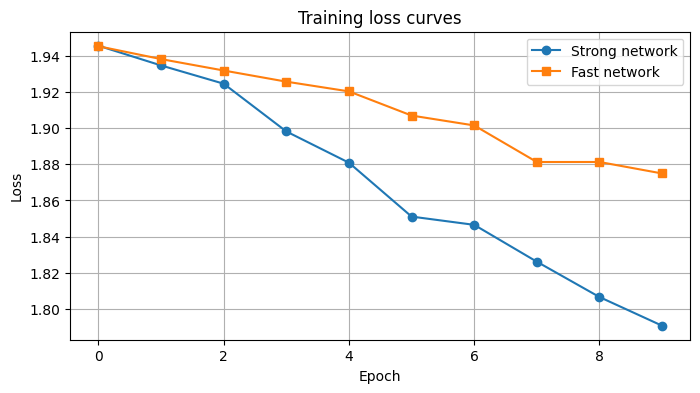

In [9]:
# ============================================================
# Section 7: Plot training curves
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(strong_history, marker='o', label='Strong network')
plt.plot(fast_history, marker='s', label='Fast network')
plt.title("Training loss curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Utility: masked policy prediction

We mask out illegal moves and normalize the remaining probabilities.

In [10]:
# ============================================================
# Section 8: Policy prediction helper
# ============================================================

def predict_masked_policy(net, env):
    net.eval()
    with torch.no_grad():
        x = torch.tensor(env.encode(), dtype=torch.float32).unsqueeze(0).to(device)
        logits = net(x)[0].cpu().numpy()

    probs = np.exp(logits - np.max(logits))
    legal = env.legal_moves()

    masked = np.zeros_like(probs, dtype=np.float32)
    masked[legal] = probs[legal]

    if masked.sum() == 0:
        masked[legal] = 1.0 / len(legal)
    else:
        masked = masked / masked.sum()

    return masked

In [11]:
# ============================================================
# Section 9: Mixed Neural MCTS
# ============================================================

def fast_policy_rollout(env, fast_net, max_steps=42):
    rollout_env = env.clone()

    for _ in range(max_steps):
        if rollout_env.is_terminal():
            break

        probs = predict_masked_policy(fast_net, rollout_env)
        legal = rollout_env.legal_moves()
        move = sample_move_from_distribution(probs, legal, temperature=1.0)
        rollout_env.apply_move(move)

    return rollout_env.result_for_player(env.current_player)

class MixedNeuralMCTS:
    def __init__(self, strong_net, fast_net, num_simulations=200, c_puct=1.5):
        self.strong_net = strong_net
        self.fast_net = fast_net
        self.num_simulations = num_simulations
        self.c_puct = c_puct

    def puct_score(self, parent, child):
        exploit = -child.q
        explore = self.c_puct * child.prior * math.sqrt(parent.visits + 1) / (1 + child.visits)
        return exploit + explore

    def expand_with_priors(self, node):
        priors = predict_masked_policy(self.strong_net, node.state)
        legal_moves = node.state.legal_moves()

        for move in list(node.untried_moves):
            child_state = node.state.clone()
            child_state.apply_move(move)
            node.add_child(move, child_state, prior=float(priors[move]))

    def select_child(self, node):
        return max(node.children.values(), key=lambda child: self.puct_score(node, child))

    def search(self, root_state):
        root = MCTSNode(root_state.clone())

        # Expand root immediately with priors if possible
        if not root.state.is_terminal() and len(root.untried_moves) > 0:
            self.expand_with_priors(root)

        for _ in range(self.num_simulations):
            node = root

            # Selection phase
            while not node.state.is_terminal() and len(node.children) > 0:
                node = self.select_child(node)

            # Expansion phase
            if not node.state.is_terminal() and len(node.untried_moves) > 0:
                self.expand_with_priors(node)
                if len(node.children) > 0:
                    node = self.select_child(node)

            # Simulation phase
            value = fast_policy_rollout(node.state, self.fast_net)

            # Backpropagation
            while node is not None:
                node.visits += 1
                node.value_sum += value
                value = -value
                node = node.parent

        visit_counts = np.zeros(ConnectFour.COLS, dtype=np.float32)
        for move, child in root.children.items():
            visit_counts[move] = child.visits

        best_move = int(np.argmax(visit_counts))
        return best_move, root

In [12]:
# ============================================================
# Section 10: Baseline UCT agent
# ============================================================

class BaselineUCT:
    def __init__(self, num_simulations=200, c=1.4):
        self.num_simulations = num_simulations
        self.c = c

    def uct_score(self, parent, child):
        if child.visits == 0:
            return float("inf")
        exploit = -child.q
        explore = self.c * math.sqrt(math.log(parent.visits + 1) / child.visits)
        return exploit + explore

    def select_child(self, node):
        return max(node.children.values(), key=lambda child: self.uct_score(node, child))

    def search(self, root_state):
        root = MCTSNode(root_state.clone())

        for _ in range(self.num_simulations):
            node = root

            while (
                not node.state.is_terminal()
                and node.is_fully_expanded()
                and len(node.children) > 0
            ):
                node = self.select_child(node)

            if not node.state.is_terminal() and len(node.untried_moves) > 0:
                move = random.choice(node.untried_moves)
                nxt = node.state.clone()
                nxt.apply_move(move)
                node = node.add_child(move, nxt)

            value = random_rollout(node.state)

            while node is not None:
                node.visits += 1
                node.value_sum += value
                value = -value
                node = node.parent

        best_move = max(root.children.items(), key=lambda x: x[1].visits)[0]
        return best_move, root

In [13]:
# ============================================================
# Section 11: Agent wrappers
# ============================================================

class RandomAgent:
    def choose_move(self, env):
        return random.choice(env.legal_moves())

class UCTAgent:
    def __init__(self, sims=120):
        self.searcher = BaselineUCT(num_simulations=sims, c=1.4)

    def choose_move(self, env):
        move, _ = self.searcher.search(env)
        return move

class MixedNeuralAgent:
    def __init__(self, strong_net, fast_net, sims=120):
        self.searcher = MixedNeuralMCTS(strong_net, fast_net, num_simulations=sims, c_puct=1.5)

    def choose_move(self, env):
        move, _ = self.searcher.search(env)
        return move

def play_game(agent1, agent2):
    env = ConnectFour()
    while not env.is_terminal():
        if env.current_player == 1:
            move = agent1.choose_move(env.clone())
        else:
            move = agent2.choose_move(env.clone())
        env.apply_move(move)
    return env.winner

def evaluate_agents(agent1, agent2, num_games=20):
    results = {1: 0, -1: 0, 0: 0}
    for g in range(num_games):
        if g % 2 == 0:
            winner = play_game(agent1, agent2)
            results[winner] += 1
        else:
            winner = play_game(agent2, agent1)
            if winner == 1:
                results[-1] += 1
            elif winner == -1:
                results[1] += 1
            else:
                results[0] += 1
    return results

In [15]:
# ============================================================
# Section 12: Run experiments
# ============================================================

mixed_agent = MixedNeuralAgent(strong_net, fast_net, sims=120)
uct_agent = UCTAgent(sims=120)
random_agent = RandomAgent()

print("Mixed Neural MCTS vs Random")
print(evaluate_agents(mixed_agent, random_agent, num_games=20))

Mixed Neural MCTS vs Random
{1: 20, -1: 0, 0: 0}


In [16]:
print("UCT vs Random")
print(evaluate_agents(uct_agent, random_agent, num_games=20))

UCT vs Random
{1: 20, -1: 0, 0: 0}


In [17]:
print("Mixed Neural MCTS vs UCT")
print(evaluate_agents(mixed_agent, uct_agent, num_games=20))

Mixed Neural MCTS vs UCT
{1: 8, -1: 11, 0: 1}



This notebook extends the previous idea further:

- **Selection** is guided by a strong neural policy
- **Simulation** is guided by a fast neural policy
